<span style="font-size:32px; font-weight:bold;"> Library Imports </span>

Python Version also printed. </span>

In [2]:
import sys
print("Python version:", sys.version)
import site
print(sys.executable)
print(site.getsitepackages())
import numpy
print(numpy.__file__)

Python version: 3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]
c:\Users\nnaji\AppData\Local\Programs\Python\Python313\python.exe
['c:\\Users\\nnaji\\AppData\\Local\\Programs\\Python\\Python313', 'c:\\Users\\nnaji\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\site-packages']
c:\Users\nnaji\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\__init__.py


In [ ]:

#Import Libraries
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from keras.models import Sequential
from keras.layers import Dense, LSTM
from keras.optimizers import Adam
import os
import sys
import seaborn as sns
pass

<span style="font-size:32px; font-weight:bold;">Data Preprocessing</span>

Specify the Learning Rate

In [4]:
learning_rate = 0.0005
#The learning rate determines the steps size in the direction oppposite to the gradient of the loss function. 
#A smaller learning rate means the model learns more slowly but can achieve better accuracy, while a larger learning rate speeds up training but may overshoot the optimal solution.
# Create an Adam optimizer with the specified learning rate 
curr_dir = os.getcwd()
print(curr_dir)

c:\Users\nnaji\OneDrive\Documents\GitHub\UGRA_LSTM_Solar-Prediction\File Versions py files


In [5]:

# Load Dataset
df = pd.read_csv('BigData.csv')
#df = pd.read_csv('MedData.csv')
#df = pd.read_csv('SmallBigData.csv')



Preprocessing

<span style="font-size:32px; font-weight:bold;">Feature Engineering</span><br>

<span style="font-size:24px; font-weight:bold; font-style:italic;">Person correlation coefficient</span><br>
This is used to find linear relationships between features<br>

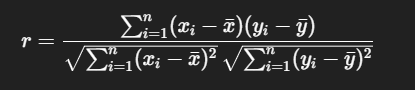

$x_i, y_i$ = sample points <br>$\bar{x}, \bar{y}$ = means <br> 𝑟 ranges from -1 (perfect negative correlation) to +1 (perfect positive correlation).


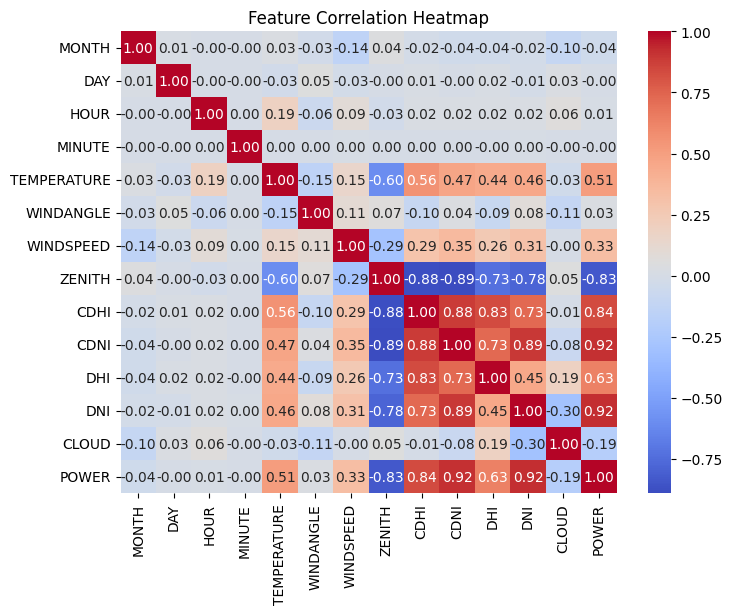

In [6]:

#plotted the features to make sure there are not missing data points. 
import seaborn as sns

#Correlation Heatmap-- The purpose of this visualization is to show linear relationships between different features in the datasat.
#Relatioships are plotted on a scale of -1 to 1, where 1 means a perfect positive correlation, -1 means a perfect negative correlation, and 0 means no correlation.
#Correlation is calculated using
plt.figure(figsize=(8,6))
heatmap = sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
# plt.show()
pass

<span style="font-size:24px; font-weight:bold; font-style:italic;">Key Takeaways</span><br>

The Power output has strong correlations with with: CDHI, CDNI, DHI, DNI (~0.9)
    This makes sense because more sunlight means more solat power. 

<span style="font-size:24px; font-weight:bold; font-style:italic;">Spearman Relation Coefficient</span><br>
This is used to find the Spearman relationships between features. Based upon "rank" relationship. <br>

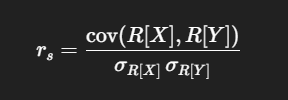

$R[X]$ = ranks of the $X$ values; <br>
$R[Y]$ = ranks of the $Y$ values; <br>
$\operatorname{cov}(R[X], R[Y])$ = covariance of the rank vectors; <br>
$\sigma_{R[X]},\ \sigma_{R[Y]}$ = standard deviations of the ranks.


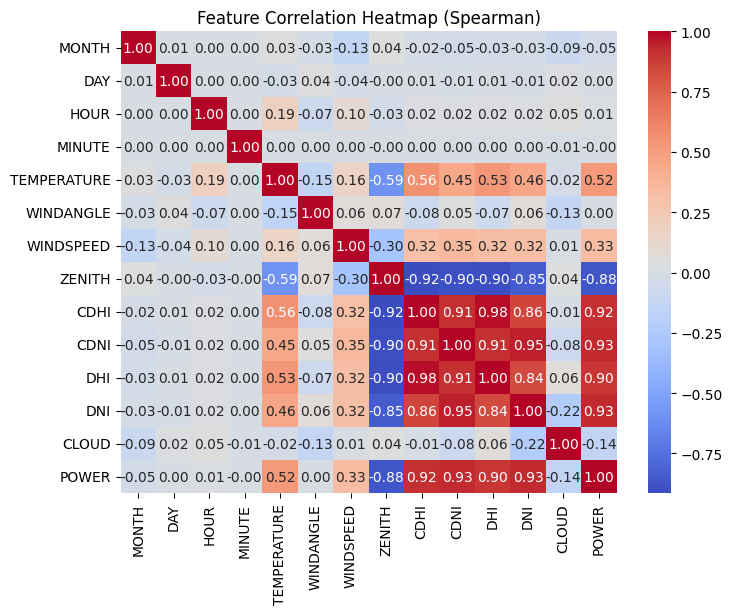

In [7]:
#Compute Spearman correlation
spearman_corr = df.corr(method='spearman')

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Feature Correlation Heatmap (Spearman)")
plt.show()

utilizing the Spearman and Pearson to find correlations in the data  increases the robustness of the model. 

Code Below Plots the features with significant amounts of outliers.

<span style="font-size:24px; font-weight:bold; font-style:italic;">Outliers are plotted.</span><br>
Features with >0 Outliers are plotted.
Features with no outliers were not plotted at all.

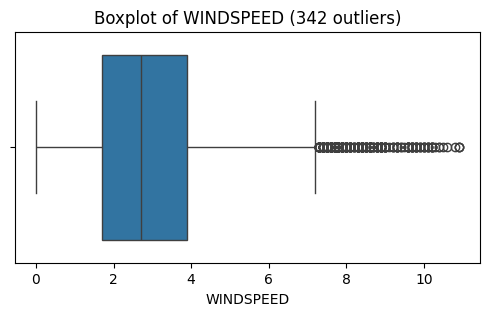

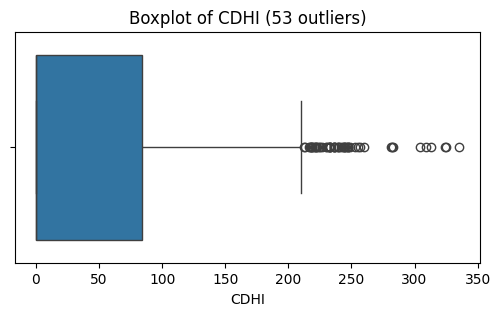

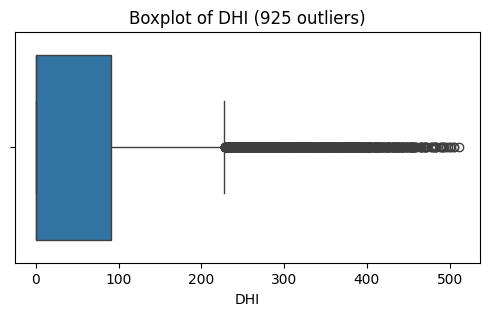

In [8]:
for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)][col]
    if len(outliers) > 0:
        plt.figure(figsize=(6, 3))
        sns.boxplot(x=df[col])
        plt.title(f"Boxplot of {col} ({len(outliers)} outliers)")
        plt.show()

In [9]:
#Loading my dataset
df = pd.read_csv('BigData.csv')  
features_per_fig = 4
num_features = len(df.columns)
num_figs = (num_features + features_per_fig - 1) // features_per_fig
colors = cm.get_cmap('tab20', num_features)

C:\Users\nnaji\AppData\Local\Temp\ipykernel_12928\1477816662.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab20', num_features)


In [ ]:
for i in range(num_figs):
    fig, axs = plt.subplots(features_per_fig, 1, figsize=(12, 8), sharex=True)
    fig.suptitle(f"Feature Time Series (Part {i+1})", fontsize=16)

    for j in range(features_per_fig):
        idx = i * features_per_fig + j
        if idx >= num_features:
            axs[j].axis('off')
            continue
        col = df.columns[idx]
        axs[j].plot(df[col], label=col, linewidth=1.2, color=colors(idx))
        axs[j].set_ylabel(col)
        axs[j].legend(loc='upper right')
        axs[j].grid(True)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()



<span style="font-size:24px; font-weight:bold; font-style:italic;">Seperate Prediction Variables. Normalize and Reshape</span><br>

In [12]:
solar_Xdata = df.copy()
solar_ydata = solar_Xdata.pop("POWER")

In [13]:
solar_Xdata = solar_Xdata.values.reshape(-1,solar_Xdata.shape[1])
solar_ydata = solar_ydata.values.reshape(-1,1)

In [14]:
# Normalize Data
X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

solar_XdataN = X_scaler.fit_transform(solar_Xdata)
solar_ydataN = y_scaler.fit_transform(solar_ydata)